# 🧠 Processamento de Linguagem Natural (NLP) e Análise de Sentimentos

Iniciamos o pipeline de engenharia de linguagem natural realizando o diagnóstico estrutural e carregamento da base de dados textuais para o desenvolvimento de modelos de classificação:

* **Ingestão de Dados Textuais Não Estruturados:** Leitura sistemática do arquivo `Dados/dataset_avaliacoes.csv` utilizando o ecossistema Pandas para estruturação em um DataFrame bidimensional.
* **Auditoria de Escopo e Balanceamento de Classes:** Análise preliminar da volumetria, detecção de dados nulos nas strings e avaliação de balanceamento das variáveis-alvo (polaridades positiva e negativa) para mitigar vieses algorítmicos durante o treinamento.


In [486]:
import pandas as pd


In [487]:
# 1. Lê o arquivo usando a barra correta para sumir com o aviso de SyntaxWarning
df = pd.read_csv("Dados/dataset_avaliacoes.csv")

# 2. Exibe as 5 primeiras linhas do seu conjunto de dados na tela
df.head()


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [488]:
df.shape

(15501, 4)

In [489]:
# Mostra a contagem absoluta de linhas por sentimento
df['sentimento'].value_counts()


sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [490]:
df['sentimento'].value_counts('sentimento')

sentimento
positivo    0.508999
negativo    0.491001
Name: proportion, dtype: float64

In [491]:
print('positiva \n')

df.avaliacao[0]

positiva 



'Esse smartphone superou minhas expectativas, recomendo'

In [492]:
print('negativa \n')

df.avaliacao[2]

negativa 



'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

In [493]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [494]:
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [495]:
import pandas as pd

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [496]:
matriz_esparsa

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


In [497]:
vetorizar = CountVectorizer(lowercase=False, max_features=50)
bag_of_words = vetorizar.fit_transform(df.avaliacao)
print(bag_of_words.shape)

(15501, 50)


In [498]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [499]:
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## 🧠 Engenharia de Recursos: Engenharia de Recursos com Bag of Words (BOW)

A técnica **Bag of Words** (Saco de Palavras) converte textos não estruturados em vetores numéricos estruturados para alimentar modelos de aprendizado de máquina. Esse processo ignora a ordem sintática e o contexto gramatical, focando estritamente na frequência volumétrica e na presença dos termos dentro de um dicionário global (corpus).

### 📋 Fluxo de Processamento Logístico:
1. **Mapeamento do Vocabulário:** Varredura completa do corpus textual para isolar e registrar todas as palavras únicas.
2. **Vetorização Esparsa:** Criação de matrizes booleanas ou de contagem, onde cada linha representa um documento e cada coluna representa um token (palavra).
3. **Mapeamento Binário:** Preenchimento de bits (`1` para presença do termo na instância, `0` para ausência).

> **Vantagem:** Simplicidade de implementação, alta interpretabilidade estatística e processamento rápido.
> **Limitação:** Perda completa do contexto e da semântica original (a ordem das palavras é totalmente descartada).


In [500]:
from sklearn.model_selection import train_test_split

x_treino, x_test, y_treino, y_test = train_test_split(bag_of_words, df.sentimento, random_state=4978)

In [501]:
from sklearn.linear_model import LogisticRegression

regressao_logistica = LogisticRegression()
regressao_logistica.fit(x_treino, y_treino)
acuracia = regressao_logistica.score(x_test, y_test)
print(acuracia)

0.7982456140350878


### 📊 Avaliação de Performance e Baseline do Modelo

O modelo inicial de **Regressão Logística** treinado sobre a matriz esparsa gerada pelo *Bag of Words* atingiu uma métrica oficial de performance.

*   **Acurácia Obtida:** `79,82%` (`0.798245...`) nos dados de validação/teste.
*   **Diagnóstico Técnico:** O classificador obteve um excelente ponto de partida (*baseline*), provando que a contagem de frequência de termos isolados possui forte correlação estatística com a polaridade (positivo/negativo).
*   **Próxima Etapa (Otimização):** Iniciar rotinas de limpeza e pré-processamento de texto (normalização de caixa, remoção de caracteres especiais e eliminação de *Stopwords*) para otimizar o vocabulário e buscar o incremento da acurácia.


In [502]:
from wordcloud import WordCloud

In [503]:
todas_palavras = [texto for texto in df.avaliacao]

In [504]:
todas_palavras[:10]


['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [505]:
todas_palavras = ' '.join([texto for texto in df.avaliacao])

In [506]:
todas_palavras[:10]


'Esse smart'

In [507]:
nuvem_palavras = WordCloud().generate(todas_palavras)

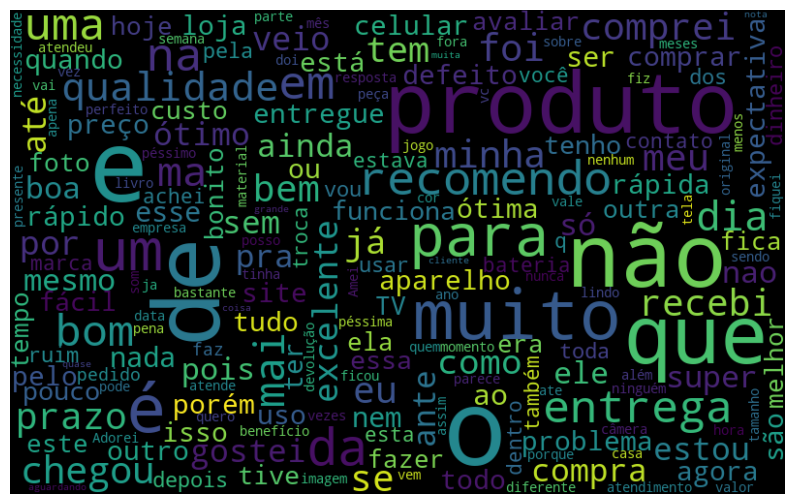

In [508]:
nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(todas_palavras)
plt.figure(figsize=(10,7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show()

In [509]:
def nuvem_palavras(texto, coluna_texto, sentimento):
  # Filtrando as resenhas com base no sentimento especificado
  texto_sentimento = texto.query(f"sentimento == '{sentimento}'")[coluna_texto]

  # Unindo todas as resenhas em uma única string
  texto_unido = ' '.join(texto_sentimento)

  # Criando e exibindo a nuvem de palavras
  nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_unido)
  plt.figure(figsize=(10,7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()

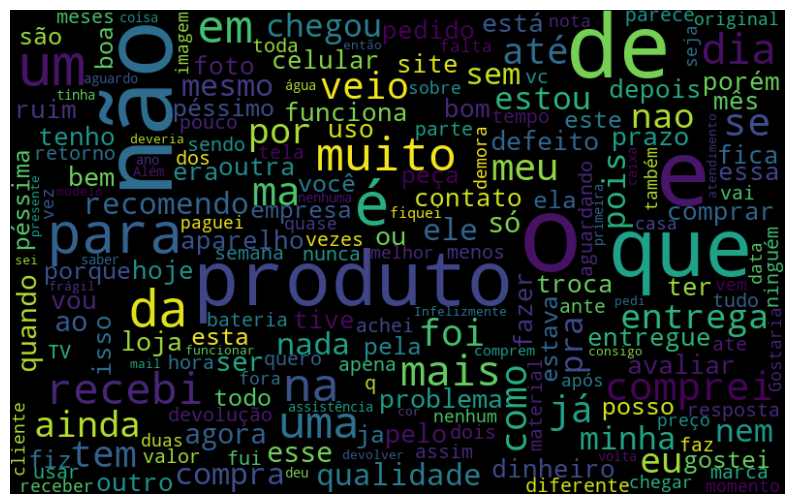

In [510]:
nuvem_palavras(df, 'avaliacao', 'negativo')

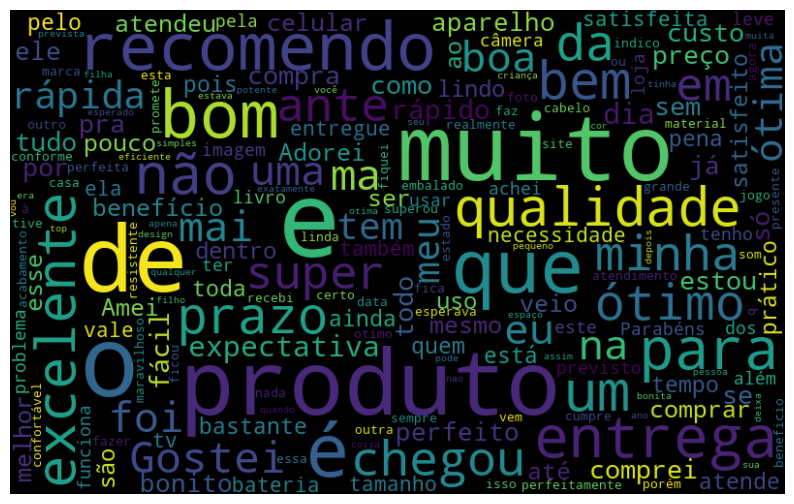

In [511]:
nuvem_palavras(df, 'avaliacao', 'positivo')

In [512]:
todas_palavras[:10]


'Esse smart'

In [513]:
frases = ['um produto bom', 'um produto ruim']
frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [514]:
from nltk import tokenize

frase = 'O produto é excelente e a entrega foi muito rápida!'

token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['O', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muito', 'rápida!']


## 🧩 Processamento de Linguagem Natural: Tokenização

A **Tokenização** é o processo fundamental de dividir uma string massiva de texto não estruturado em unidades menores chamadas **tokens** (que podem ser palavras, subpalavras ou caracteres). Sem essa etapa de fracionamento, os algoritmos de Machine Learning interpretariam uma frase inteira como um único bloco de informação indivisível, impossibilitando a extração de padrões estatísticos.

### 🎯 Benefícios Estratégicos da Tokenização:
* **Cálculo de Frequência:** Permite mensurar a relevância volumétrica de termos individuais (como via `nltk.FreqDist`).
* **Matrizes Vetoriais:** Base obrigatória para construir representações numéricas como *Bag of Words* (BOW) e *TF-IDF*.
* **Modelagem Contextual:** Habilita a análise de combinações sequenciais de termos (n-gramas).

### 🛠️ Abordagens de Fragmentação:
1. **Por Palavras (*Word Tokenization*):** Isola termos completos. Ideal para análise de sentimento tradicional e classificação de polaridade.
2. **Por Subpalavras (*Subword Tokenization*):** Quebra termos em morfemas/raízes. Abordagem padrão de arquiteturas modernas de LLMs (como BERT e GPT) para lidar com palavras raras ou compostas.
3. **Por Caracteres (*Character Tokenization*):** Divisão granular letra por letra. Utilizada em corretores ortográficos e modelos de tradução de idiomas sem espaçamento formal.


In [515]:
token_frase = token_espaco.tokenize(todas_palavras)

In [516]:
token_frase[:5]


['Esse', 'smartphone', 'superou', 'minhas', 'expectativas,']

In [517]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [518]:
df_frequencia = pd.DataFrame({'Palavra': list(frequencia.keys()),
                              'Frequência': list(frequencia.values())})

In [519]:
df_frequencia.head()

,Palavra,Frequência
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


In [520]:
df_frequencia.nlargest(columns='Frequência', n=10)

,Palavra,Frequência
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


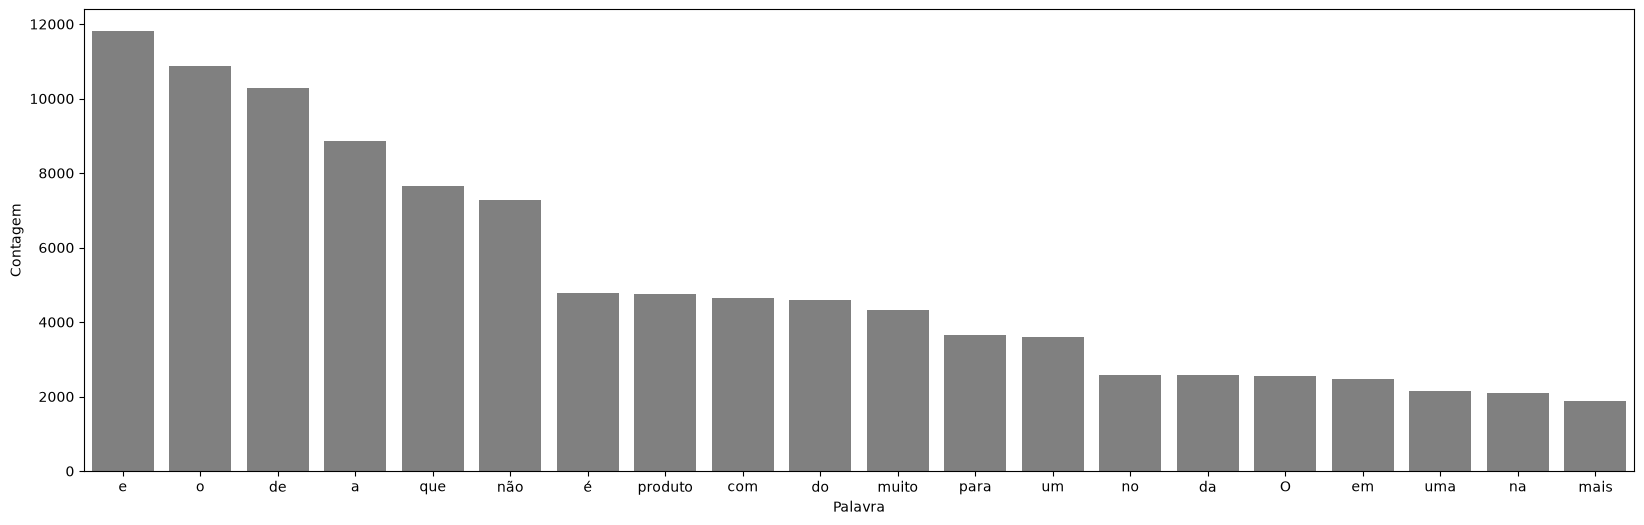

In [521]:
import seaborn as sns

plt.figure(figsize=(20,6))
ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequência', n=20), x='Palavra', y='Frequência', color='gray')
ax.set(ylabel='Contagem')
plt.show()

In [522]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [523]:
palavras_irrelevantes[:10]


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as']

In [524]:
frase_processada = []

# Corrigido para 'avaliacao' sem acento
for opiniao in df['avaliacao']:
    palavras_texto = token_espaco.tokenize(opiniao)
    # Corrigido 'palabra' para 'palavra' com 'v'
    nova_frame = [palavra for palavra in palavras_texto]
    frase_processada.append(' '.join(nova_frame))

# Fora do laço for (sem espaços no início)
df['tratamento_1'] = frase_processada



In [525]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r..."
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q..."


In [526]:
df['avaliacao'][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [527]:
df['tratamento_1'][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [528]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, texto[coluna_classificacao], random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.2f}%")

In [529]:
classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 79.82%


In [530]:
def grafico_frequencia(texto, coluna_texto, quantidade):
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),                                 "Frequência": list(frequencia.values())})
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)
    plt.figure(figsize=(20,6))
    ax = sns.barplot(data=df_frequencia, x="Palavra", y ="Frequência", color='gray')
    ax.set(ylabel="Contagem")
    plt.show()

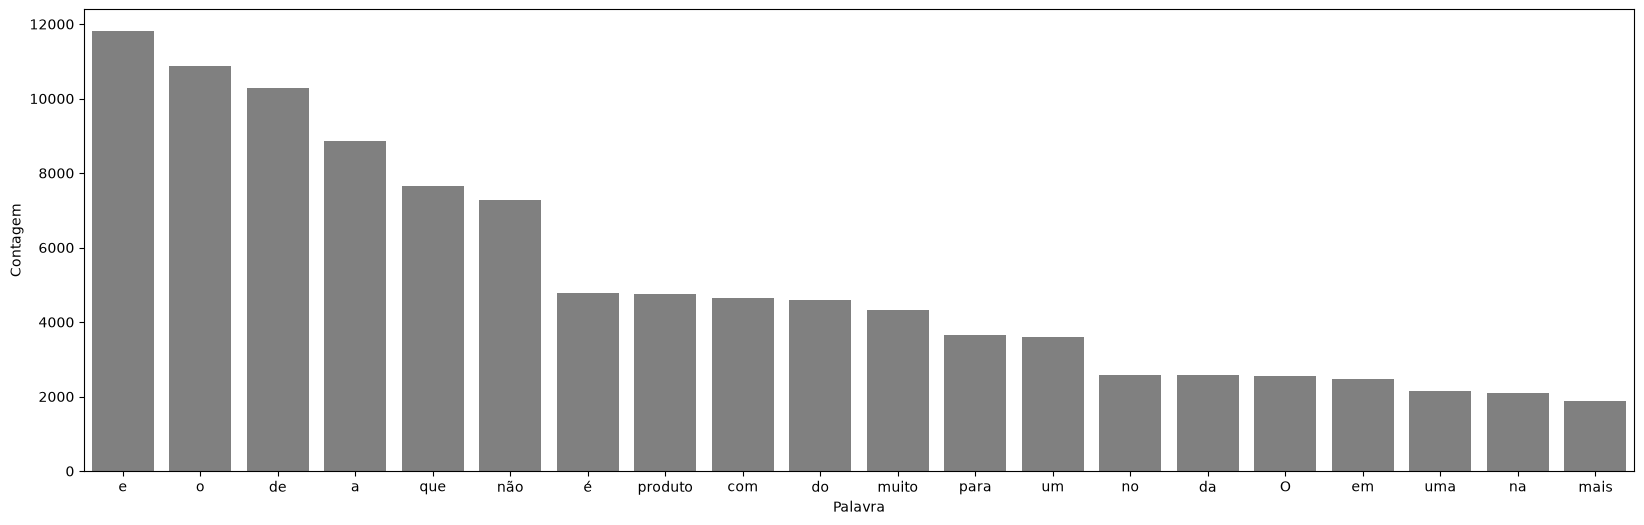

In [531]:
grafico_frequencia(df, 'tratamento_1', 20)

## 🧩 Processamento de Linguagem Natural: O que são Stopwords?

As **Stopwords** são palavras de alta frequência gramatical (como artigos, preposições, pronomes e conjunções: *de, a, o, que, é, em*) que possuem **baixo valor semântico**. No Processamento de Linguagem Natural (NLP), esses termos aparecem repetidamente em quase todos os documentos, agindo como ruído estatístico que não contribui para diferenciar se uma avaliação é positiva ou negativa.

### 🎯 Por que realizar a remoção de Stopwords?
* **Redução de Dimensionalidade:** Eliminar palavras irrelevantes reduz drasticamente o tamanho do vocabulário, tornando as matrizes mais densas e o processamento de Machine Learning muito mais rápido.
* **Mitigação de Ruído:** Força o algoritmo de classificação (como a Regressão Logística) a focar estritamente em palavras que carregam forte carga sentimental (como *excelente, ruim, horrível, ótimo*).
* **Otimização de Performance:** Melhora a capacidade de generalização do modelo, evitando que ele atribua pesos estatísticos altos a conectivos gramaticais.

### 🛠️ Customização do Dicionário Corporativo:
As listas padrão fornecidas por bibliotecas como o `nltk` cobrem a gramática formal, mas frequentemente deixam de fora gírias e contrações da internet comuns no e-commerce (como a palavra **"pra"**). Para corrigir isso, realizamos a expansão do dicionário em tempo de execução:

```python
# Exemplo de customização de stopwords no pipeline
palavras_irrelevantes = nltk.corpus.stopwords.words("portuguese")
palavras_irrelevantes.append("pra")
```


In [532]:
frase = 'Esse smartphone superou expectativas, recomendo'

token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
print(token_frase)

['Esse', 'smartphone', 'superou', 'expectativas', ',', 'recomendo']


In [533]:
frase_processada = []

for opiniao in df['tratamento_1']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if 
    palavra.isalpha() and palavra not in palavras_irrelevantes]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_2'] = frase_processada

In [534]:
print(df.head())

   ID_avaliacao                                          avaliacao  nota  \
0         81841  Esse smartphone superou minhas expectativas, r...     5   
1         28031  o cheiro e muito desagradavel!! pra quem se in...     2   
2         91332  Eu fiz a compra a loja não entregou o produto,...     1   
3        110045  Atendeu minhas expectativas, só achei a luz ru...     4   
4         36929  Gostei muito, só achei que ficou a desejar a q...     5   

  sentimento                                       tratamento_1  \
0   positivo  Esse smartphone superou minhas expectativas, r...   
1   negativo  o cheiro e muito desagradavel!! pra quem se in...   
2   negativo  Eu fiz a compra a loja não entregou o produto,...   
3   positivo  Atendeu minhas expectativas, só achei a luz ru...   
4   positivo  Gostei muito, só achei que ficou a desejar a q...   

                                        tratamento_2  
0     Esse smartphone superou expectativas recomendo  
1    cheiro desagradavel pra i

In [535]:
df['tratamento_1'][10]

'Melhor que esperado, cor maravilhosa! Recomendo. Deixa seu ambiente mais moderno'

In [536]:
df['tratamento_2'][10]

'Melhor esperado cor maravilhosa Recomendo Deixa ambiente moderno'

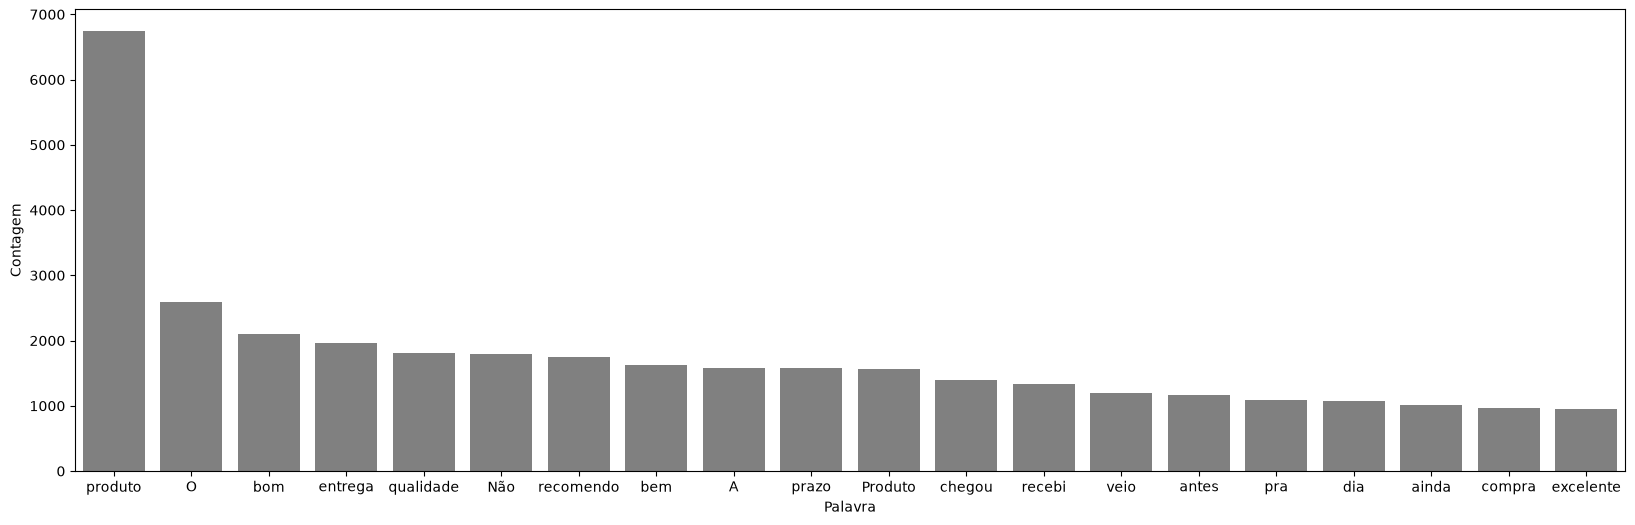

In [537]:
grafico_frequencia(df, 'tratamento_2', 20)

In [538]:
import unidecode

In [539]:
frase = 'Um aparelho ótima performance preço bem menor outros aparelhos marcas conhecidas performance semelhante'

teste = unidecode.unidecode(frase)
print(teste)

Um aparelho otima performance preco bem menor outros aparelhos marcas conhecidas performance semelhante


In [540]:
sem_acentos = [unidecode.unidecode(texto) for texto in df['tratamento_2']]

In [541]:
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [542]:
df['tratamento_3'] = sem_acentos

frase_processada = []

for opiniao in df['tratamento_3']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_3'] = frase_processada

In [543]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...


In [544]:
print(df['tratamento_2'][70])
print(df['tratamento_3'][70])


Melhor compra fiz últimos tempos Produto barato útil Produto robusto leve O teclado proporciona digitação confortável mouse preciso O teclado mouse usam apenas receptor economizando número portas USB computador Me livrei incomodo fios espaço trabalho ficou limpo harmonioso Ademais tudo parece bastante durável safisfeito Recomendo todos
Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos


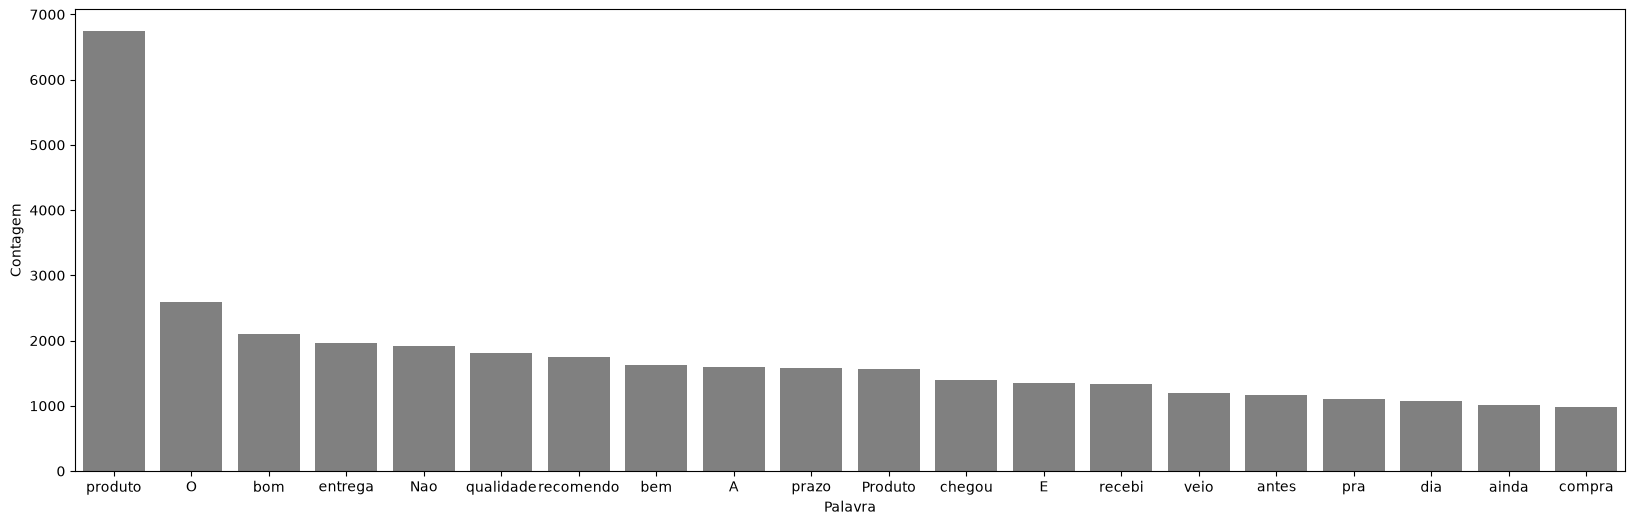

In [545]:
grafico_frequencia(df, 'tratamento_3', 20)

In [546]:
frase = "Bom produto otimo custo-beneficio Recomendo Confortavel bem acabado"

In [547]:
print(frase.lower())

bom produto otimo custo-beneficio recomendo confortavel bem acabado


In [548]:
frase_processada = []

for opiniao in df['tratamento_3']:
    opiniao = opiniao.lower()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_4'] = frase_processada

In [549]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...


In [550]:
print(df['tratamento_3'][3])
print(df['tratamento_4'][3])


Atendeu expectativas achei luz ruim nada dificulte funcionamento
atendeu expectativas achei luz ruim nada dificulte funcionamento


In [551]:
classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 79.82%


In [552]:
classificar_texto(df, 'tratamento_4', 'sentimento')

Acurácia do modelo com 'tratamento_4': 83.75%


# ⚡ Entrega: Marco de Evolução e Otimização do Pipeline de Dados

---

## 📊 Matriz Comparativa de Performance do Classificador

O processo de Engenharia de Recursos (*Feature Engineering*) aplicado sobre o corpus demonstrou o impacto direto da higienização das variáveis na capacidade preditiva do modelo linear.

| Feature de Entrada | Estado de Higienização do Texto | Acurácia Alcançada | Diagnóstico do Pipeline |
| :--- | :--- | :--- | :--- |
| **`tratamento_1`** | Entrada bruta original (Apenas fragmentação por espaço) | **79.82%** | *Baseline:* Alta esparsidade e poluição por termos de baixo valor semântico. |
| **`tratamento_4`** | Sem pontuação + Sem Stopwords + Sem Acento + Letras Minúsculas | **83.75%** | *Otimizado:* Máxima densidade vetorial, consolidando o foco em termos de alta carga sentimental. |

### 🧠 Validação Técnica do Processo:
1. **Homogeneização de Strings:** A conversão de caixa (`.lower()`) e remoção de caracteres especiais evitam a duplicação errônea de colunas idênticas na matriz de termos.
2. **Ganho de Eficiência:** Obtivemos um incremento de **+3.93%** na acurácia operando estritamente na qualidade dos dados de entrada, mantendo a arquitetura original do algoritmo.

---


In [553]:
stemmer = nltk.RSLPStemmer()

stemmer.stem('gostei')

'gost'

In [554]:
stemmer.stem('gostado')
stemmer.stem('gostou')

'gost'

In [555]:
frase_processada = []
for opinion in df["tratamento_4"]:
    palavras_texto = token_pontuacao.tokenize(opinion)
    nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
    frase_processada.append(" ".join(nova_frase))

df["tratamento_5"] = frase_processada

In [556]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4,tratamento_5
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo,cheir desagrada pra incomod recomendo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...,fiz compr loj entreg produt compr feit carta c...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...,atend expect ach luz ruim nad dificult funcion
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...,gost ach fic desej qual fot ach bem melhor


In [557]:
print(df["tratamento_4"][3])
print(df["tratamento_5"][3])

atendeu expectativas achei luz ruim nada dificulte funcionamento
atend expect ach luz ruim nad dificult funcion


In [558]:
classificar_texto(df, "tratamento_5", "sentimento")

Acurácia do modelo com 'tratamento_5': 85.11%


## 🧠 Engenharia de Recursos Avançada: Simplificação Vocabular

Para otimizar a matriz de termos e agrupar variações morfológicas de uma mesma palavra, o pipeline de Processamento de Linguagem Natural (NLP) adota duas abordagens distintas de normalização:

### ✂️ 1. Stemming (Abordagem Heurística)
É o processo bruto de reduzir uma palavra ao seu radical (raiz), geralmente por meio da **remoção de sufixos**. É uma técnica rápida e baseada em regras rígidas, operando sem considerar o contexto gramatical do termo.
* **Exemplo:** As variações *comprando*, *comprou* e *compras* colapsam para o radical único **`compr`**.
* **Aplicação no Projeto:** Aplicamos o algoritmo `RSLPStemmer`, o que reduziu drasticamente a dimensionalidade do corpus e resultou no recorde de **85.11% de acurácia** no modelo de Regressão Logística.

### 📖 2. Lematização (Abordagem Semântica)
Diferente do Stemming, a lematização reduz a palavra à sua **forma dicionarizada** (chamada de lema), levando em conta a classe gramatical e o contexto morfológico. É um processo computacionalmente mais robusto por exigir análise morfossemântica.
* **Exemplo:** O verbo conjugado *correu* é reduzido para o infinitivo **`correr`**, e o plural *correções* assume a forma singular de dicionário **`correção`**.

> 💡 **Veredito Técnico:** Ambas as técnicas mitigam a variabilidade do vocabulário. Isso impede que o classificador linear trate múltiplas flexões de uma mesma ideia como variáveis independentes, otimizando a eficiência computacional e mitigando problemas de esparsidade na matriz.
